<a href="https://colab.research.google.com/github/PavlovIO/spbu-python-course/blob/assignment7/project/hw7/Task7part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!wget https://raw.githubusercontent.com/PavlovIO/spbu-python-course/refs/heads/assignment7/project/hw7/titanic_test.csv
!wget https://raw.githubusercontent.com/PavlovIO/spbu-python-course/refs/heads/assignment7/project/hw7/titanic_train.csv
!wget https://raw.githubusercontent.com/PavlovIO/spbu-python-course/refs/heads/assignment7/project/hw7/gender_submission.csv

--2025-11-21 16:33:06--  https://raw.githubusercontent.com/PavlovIO/spbu-python-course/refs/heads/assignment7/project/hw7/titanic_test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28210 (28K) [text/plain]
Saving to: ‘titanic_test.csv.1’

titanic_test.csv.1  100%[===================>]  27.55K  --.-KB/s    in 0.002s  

2025-11-21 16:33:06 (12.2 MB/s) - ‘titanic_test.csv.1’ saved [28210/28210]

--2025-11-21 16:33:06--  https://raw.githubusercontent.com/PavlovIO/spbu-python-course/refs/heads/assignment7/project/hw7/titanic_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
H

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Подготовка данных

In [6]:
test = pd.read_csv('titanic_test.csv')
train = pd.read_csv('titanic_train.csv').set_index('PassengerId')
test_survived = pd.read_csv('gender_submission.csv')
df = test.merge(test_survived, how='inner', on='PassengerId').set_index('PassengerId')
df = pd.concat([train, df], axis=0)
df = df.reset_index()

In [7]:


df['Survived'] = df['Survived'].astype('Int64')
df['Sex'] = df['Sex'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  1309 non-null   int64   
 1   Survived     1309 non-null   Int64   
 2   Pclass       1309 non-null   category
 3   Name         1309 non-null   object  
 4   Sex          1309 non-null   category
 5   Age          1046 non-null   float64 
 6   SibSp        1309 non-null   int64   
 7   Parch        1309 non-null   int64   
 8   Ticket       1309 non-null   object  
 9   Fare         1308 non-null   float64 
 10  Cabin        295 non-null    object  
 11  Embarked     1307 non-null   object  
dtypes: Int64(1), category(2), float64(2), int64(3), object(4)
memory usage: 106.5+ KB


In [8]:
age_mean = np.mean(df['Age'].dropna().values)
age_meadian = np.quantile(df['Age'].dropna(), q=0.5)
print(age_mean, age_meadian)
df['Age'] = df['Age'].fillna(df['Age'].mean())

29.881137667304014 28.0


## Анализ таблицы

### Распределение людей по классам

Pclass
1    323
2    277
3    709
Name: PassengerId, dtype: int64


<Axes: xlabel='Pclass', ylabel='count'>

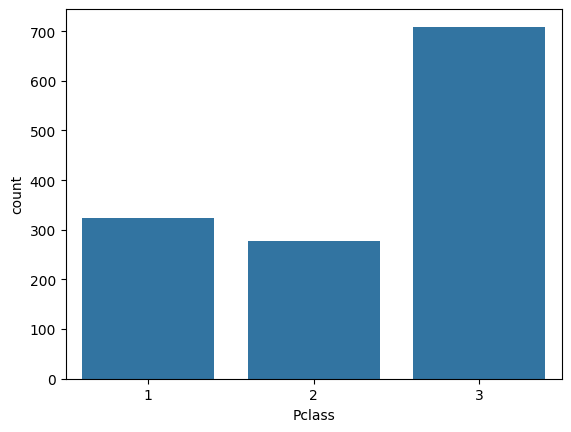

In [9]:
plass_number = df.groupby('Pclass', observed=True)['PassengerId'].count()
print(plass_number)
sns.countplot(data=df, x='Pclass')

### Средний возраст в групировке по классу и полу

  Pclass     Sex        Age
0      1  female  36.490920
1      1    male  39.285429
2      2  female  27.566636
3      2    male  30.744355
4      3  female  24.465569
5      3    male  27.106925


<Axes: xlabel='Pclass', ylabel='Age'>

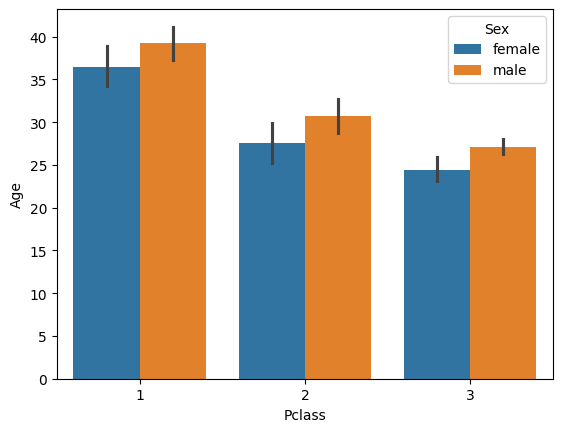

In [10]:
result = df.groupby(['Pclass', 'Sex'], as_index=False, observed=True)['Age'].mean()
print(result)
sns.barplot(data=df, x='Pclass', y='Age', hue='Sex')

### Распределение цены билета среди выживших с именем начинающемся с К

Наименьшая цена у человека с именем начинающемся с K у Kelly, Miss. Anna Katherine "Annie Kate" в классе 3 с ценой 7.75
Наибольшая цена у человека с именем начинающемся с K у Kreuchen, Miss. Emilie в классе 1 с ценой 211.3375


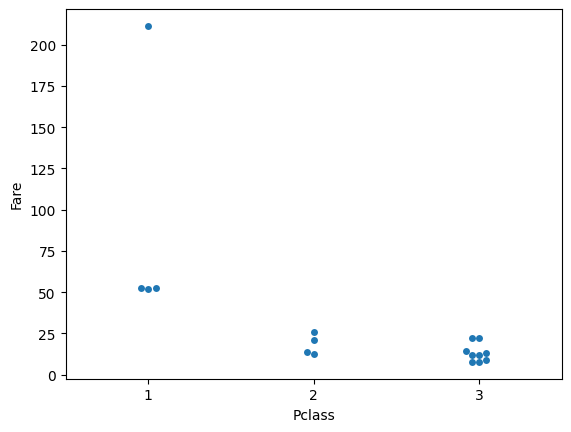

In [11]:
K_names = df[
    (df['Name'].str.contains(r'^K.+' ,regex=True, na=False)) &
    (df['Survived'] == 1)
].sort_values(by='Fare', axis=0, ascending=False)
lowest_fare = K_names.iloc[-1]
highest_fare = K_names.iloc[0]
sns.swarmplot(data=K_names, x='Pclass', y='Fare')
print(f'Наименьшая цена у человека с именем начинающемся с K у {lowest_fare.Name} в классе {lowest_fare.Pclass} с ценой {lowest_fare.Fare}')
print(f'Наибольшая цена у человека с именем начинающемся с K у {highest_fare.Name} в классе {highest_fare.Pclass} с ценой {highest_fare.Fare}')


### Максимальное количество родных с выжившим пассажиром

In [12]:
survived = df[df.Survived == 1].sort_values(by='SibSp',axis=0)
max_SibSp = survived[survived.SibSp == survived.SibSp.max()]
print(f'Набиольшее количество родственников у выжившего было у {max_SibSp.Name.iloc[0]} c {max_SibSp.SibSp.iloc[0]} родственниками')

Набиольшее количество родственников у выжившего было у Sage, Miss. Ada c 8 родственниками


## Визуализация

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  1309 non-null   int64   
 1   Survived     1309 non-null   Int64   
 2   Pclass       1309 non-null   category
 3   Name         1309 non-null   object  
 4   Sex          1309 non-null   category
 5   Age          1309 non-null   float64 
 6   SibSp        1309 non-null   int64   
 7   Parch        1309 non-null   int64   
 8   Ticket       1309 non-null   object  
 9   Fare         1308 non-null   float64 
 10  Cabin        295 non-null    object  
 11  Embarked     1307 non-null   object  
dtypes: Int64(1), category(2), float64(2), int64(3), object(4)
memory usage: 106.5+ KB


In [40]:
px.scatter(df, x='Age', y='Fare', color='Pclass', hover_data=['Name'], title='Age distribution by Fare and Class')

<Axes: xlabel='Pclass', ylabel='Fare'>

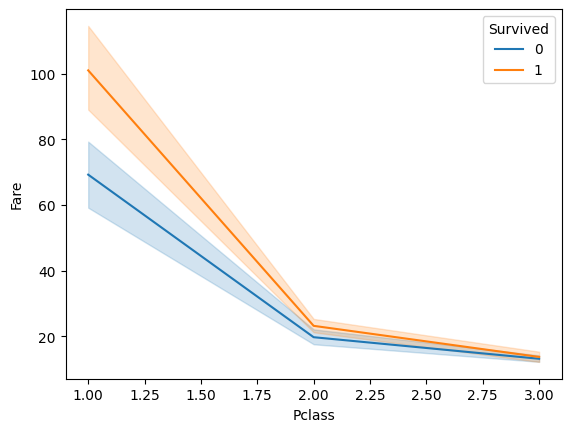

In [36]:
sns.lineplot(data=df, x='Pclass', y='Fare', hue='Survived')

In [29]:
px.histogram(df, x='Age', color='Pclass', nbins=15, opacity=0.6, title='Age distribution by Pclass')

<Axes: xlabel='Sex', ylabel='Survived'>

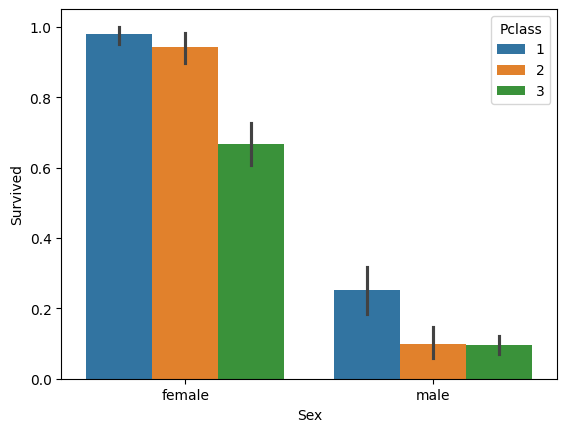

In [33]:
sns.barplot(data=df, x='Sex', y='Survived', hue='Pclass')

<Axes: xlabel='Survived', ylabel='Embarked'>

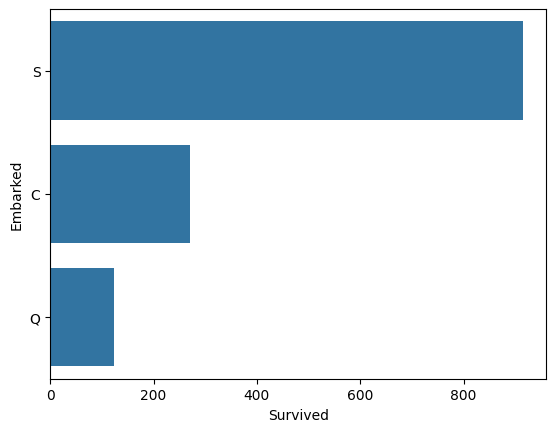

In [18]:
sns.barplot(data=df, x='Survived', y='Embarked', estimator=len)

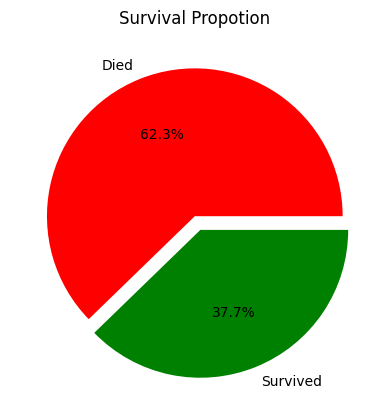

In [19]:
survived_count = df['Survived'].value_counts()
labels = ['Died', 'Survived']
plt.pie(survived_count, autopct='%1.1f%%', explode=[0,0.1], colors=['red','green'], labels=labels)
plt.title('Survival Propotion')
plt.show()

In [39]:
px.box(df, x='Pclass', y='Age', title='Age Distribution by Passenger Class')

In [58]:
fig = px.sunburst(df, path=['Pclass', 'Sex', 'Survived'])
fig.show()

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [56]:
fig = px.scatter_3d(df, x='Age', y='Fare', z='Parch',\
                    color='Survived',\
                    title='Survival by Age, Fare and Siblings/Spouses', )
fig.show()

In [38]:
px.violin(df, x='Pclass', y='Age', color='Survived', box=True, points='outliers')